In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [75]:
df = pd.read_csv('pizza_sales.csv')

In [76]:
df

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,31/12/2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31/12/2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31/12/2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31/12/2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [77]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='str')

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  str    
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  str    
 5   order_time         48620 non-null  str    
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  str    
 9   pizza_category     48620 non-null  str    
 10  pizza_ingredients  48620 non-null  str    
 11  pizza_name         48620 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 4.5 MB


In [79]:
#df['order_date'] = pd.to_datetime(df['order_date'],format ="mixed")
df['order_date'] = pd.to_datetime(df['order_date'],dayfirst =True)


In [80]:
#df['order_time'] = pd.to_datetime(df['order_time'],format = '%h')
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

In [81]:
# we find out the day week and hour of the order
df['order_day'] = df['order_date'].dt.day_name()
df['order_hour'] = df['order_time'].dt.hour

In [82]:

weekdays = ['Sunday','Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df['order_day'] = pd.Categorical(df['order_day'], categories=weekdays)
#df['order_day'] = pd.groupby

In [83]:
df['order_month'] = df['order_date'].dt.month_name()
df['order_month']

0         January
1         January
2         January
3         January
4         January
           ...   
48615    December
48616    December
48617    December
48618    December
48619    December
Name: order_month, Length: 48620, dtype: str

In [84]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['order_month'] = pd.Categorical(df['order_month'], categories=months)


## KPI calculation first

In [85]:
'''Key Performance Indicators (KPIs) 
Total Revenue = Sum of total_price 
Total Pizzas Sold = Sum of quantity 
Total Orders = Count of unique order_id 
Average Order Value (AOV) = Total Revenue ÷ Total Orders 
Average Pizza per Order = Total Pizzas Sold ÷ Total Orders 
'''

'Key Performance Indicators (KPIs) \nTotal Revenue = Sum of total_price \nTotal Pizzas Sold = Sum of quantity \nTotal Orders = Count of unique order_id \nAverage Order Value (AOV) = Total Revenue ÷ Total Orders \nAverage Pizza per Order = Total Pizzas Sold ÷ Total Orders \n'

In [86]:
# total_revenue
total_revenue = round(df['total_price'].sum(),2)
total_revenue

np.float64(817860.05)

In [87]:
# total_pizza sold
total_pizza_sales = df['quantity'].sum()
total_pizza_sales


np.int64(49574)

In [88]:
# Total_orders
Total_orders = df['order_id'].nunique()
Total_orders

21350

In [89]:
#Average_order_value
Average_order_value = total_revenue/Total_orders
Average_order_value

np.float64(38.30726229508197)

In [90]:
# Average Pizza per order
Average_Pizza_per_order = total_pizza_sales/Total_orders
Average_Pizza_per_order

np.float64(2.321967213114754)

In [ ]:
# Question number 1
# print all the KPIs
print(f"Total Revenue: ${total_revenue}")
print(f"Total Pizzas Sold: {total_pizza_sales}.qty")
print(f"Total Orders: {Total_orders}")
print(f"Average Order Value (AOV): ${Average_order_value:.2f}")
print(f"Average Pizza per Order: {Average_Pizza_per_order:.2f}")


Total Revenue: $817860.05
Total Pizzas Sold: 49574.qty
Total Orders: 21350
Average Order Value (AOV): $38.31
Average Pizza per Order: 2.32


In [92]:
#Analysis and visualization of sales trends over time, 
# such as monthly or seasonal patterns, 
# to identify peak sales periods and 
# optimize inventory management.

there is some issu the fix it

In [93]:
# I want to remove duplicates valuesd
# Remove duplicates based on pizza_id
# df = df.drop_duplicates(subset='pizza_id')
# df['pizza_id'].unique

In [ ]:
# question number 2

'''
Daily Trend

A line/bar chart showing sales by day of the week. Useful for staffing and operations planning.

'''
day_sales = df.groupby('order_day',observed = False)['revenue'].sum().reset_index()
day_sales

,order_day,revenue
0,Sunday,99203.50
1,Monday,107329.55
2,Tuesday,114133.80
3,Wednesday,114408.40
4,Thursday,123528.50
5,Friday,136073.90
6,Saturday,123182.40


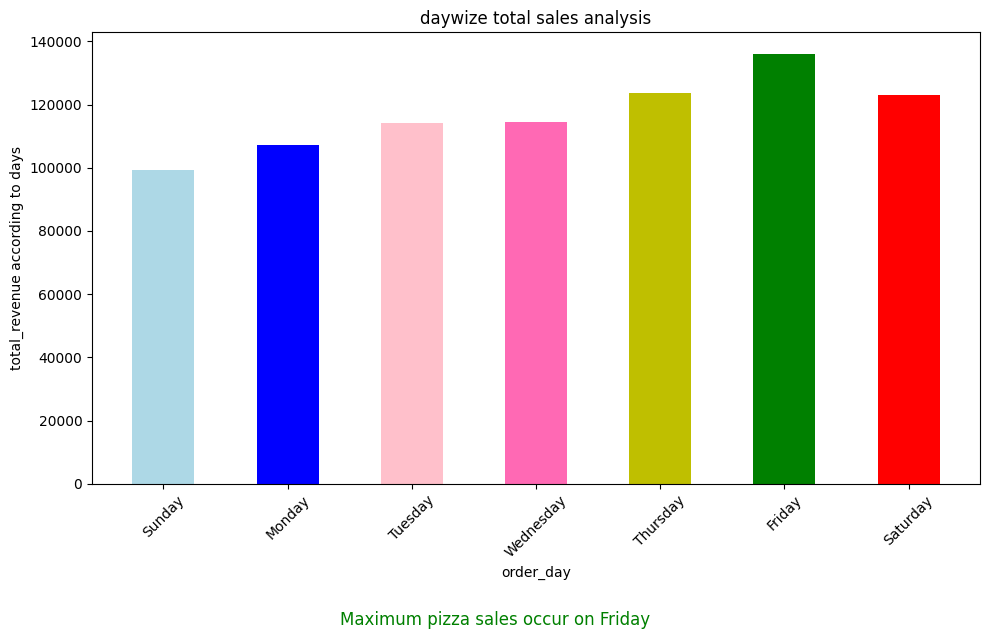

In [250]:
plt.figure(figsize=(10,6))
plt.bar(day_sales['order_day'],day_sales['revenue']
        ,width =0.5,color = ['lightblue','blue','pink','hotpink','y','g','red','lightblue'])
plt.title("daywize total sales analysis")
plt.xlabel('order_day')
plt.ylabel("total_revenue according to days")
plt.xticks(rotation =45)
plt.tight_layout()
plt.figtext(0.5, -0.05, "Maximum pizza sales occur on Friday", 
            ha="center", fontsize=12,color = 'green')
plt.show()

## question number 3 ##

## Hourly Trend A line/bar chart showing sales by hour of the day. Useful for staffing, ingredients, customer rush and operations planning ##

In [231]:
hour_sales = df.groupby('order_hour',observed = False)['total_price'].sum().reset_index()
hour_sales

,order_hour,total_price
0,9,83.00
1,10,303.65
2,11,44935.80
3,12,111877.90
4,13,106065.70
5,14,59201.40
6,15,52992.30
7,16,70055.40
8,17,86237.45
9,18,89296.85


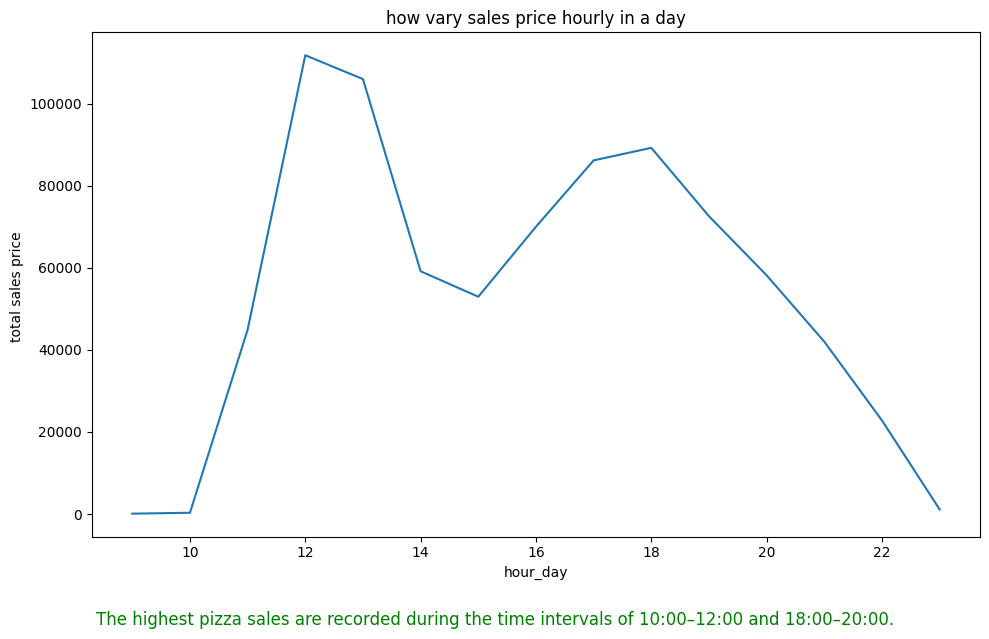

In [269]:
plt.figure(figsize = (10,6))
plt.plot(hour_sales['order_hour'],hour_sales['total_price'])
plt.title("how vary sales price hourly in a day")
plt.xlabel('hour_day')
plt.ylabel("total sales price ")
plt.tight_layout()
plt.figtext(0.5, -0.05, "The highest pizza sales are recorded during the time intervals of 10:00–12:00 and 18:00–20:00.", 
            ha="center", fontsize=12,color = 'green')
plt.show()

## question numer 4 ##

In [ ]:
'''Monthly Trend A line chart depicting monthly revenue and orders. 
Helps track seasonality and identify peak sales months. 
Summer months show higher sales due to promotional campaigns.
'''

# monthly revenue and order
order_month_sales =df.groupby('order_month',observed = False)['total_price'].sum().reset_index()
order_month_sales

,order_month,total_price
0,January,69793.30
1,February,65159.60
2,March,70397.10
3,April,68736.80
4,May,71402.75
5,June,68230.20
6,July,72557.90
7,August,68278.25
8,September,64180.05
9,October,64027.60


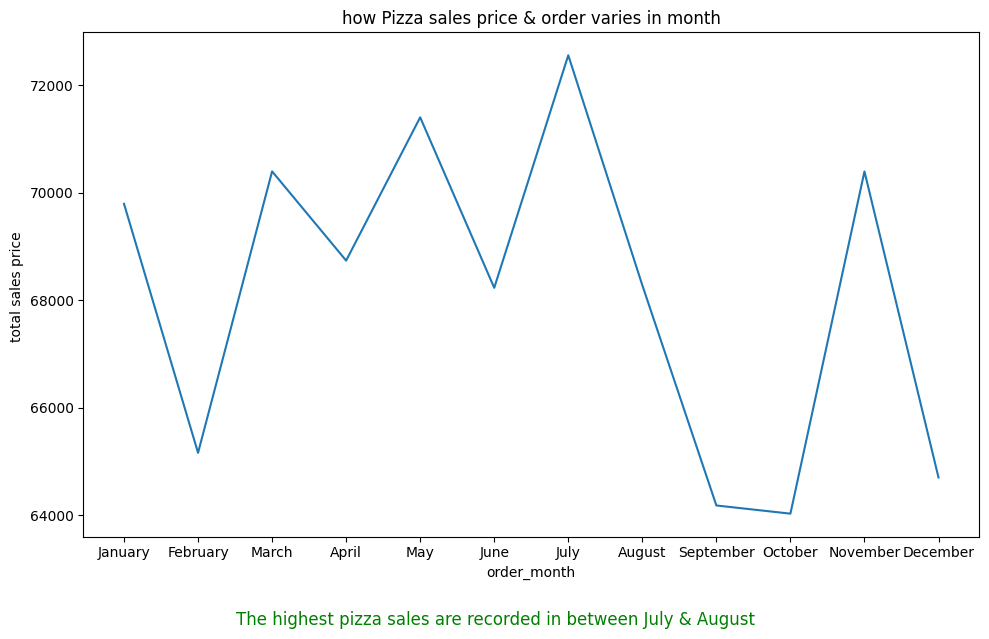

In [271]:
# visualization of monthly revenue and order

plt.figure(figsize = (10,6))
plt.plot(order_month_sales['order_month'],order_month_sales['total_price'])
plt.title("how Pizza sales price & order varies in month")
plt.xlabel('order_month')
plt.ylabel("total sales price ")
plt.tight_layout()
plt.figtext(0.5, -0.05, "The highest pizza sales are recorded in between July & August", 
            ha="center", fontsize=12,color = 'green')
plt.show()


## question number 5 ##

In [ ]:
'''
% of Sales by Category
 A bar chart representing revenue and quantity sold for each pizza category
 (Classic, Supreme, Veggie, Chicken).
 Helps identify customer preferences. 
 Classic pizzas dominate sales, while Veggie has lower demand.
'''

In [290]:
# % sales by categories 
# using without round function
sales_cat_pct = df.groupby('pizza_category')['total_price'].sum().reset_index()
sales_cat_pct['price_pct']= (sales_cat_pct['total_price']/total_revenue)*100
sales_cat_pct


,pizza_category,total_price,price_pct
0,Chicken,195919.50,23.955138
1,Classic,220053.10,26.905960
2,Supreme,208197.00,25.456311
3,Veggie,193690.45,23.682591


In [291]:
# % sales by categories 
# sales_category by 
sales_cat_pct = df.groupby('pizza_category')['total_price'].sum().reset_index()
sales_cat_pct['price_pct'] = (round(sales_cat_pct['total_price']/total_revenue, 2)*100)
sales_cat_pct

,pizza_category,total_price,price_pct
0,Chicken,195919.50,24.0
1,Classic,220053.10,27.0
2,Supreme,208197.00,25.0
3,Veggie,193690.45,24.0


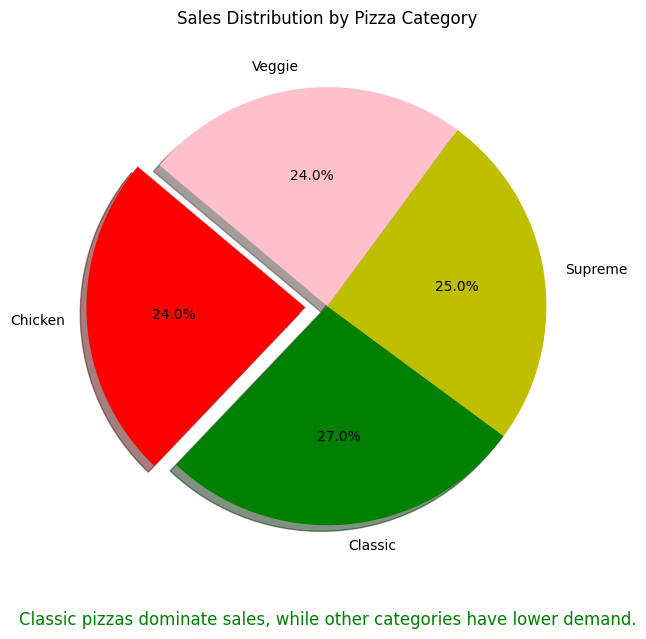

In [292]:
# pie_plot foe pizza_category with price_pct
plt.figure(figsize=(10,6))
plt.pie(
    sales_cat_pct['price_pct'],                  # values
    labels=sales_cat_pct['pizza_category'],      # labels
    autopct='%1.1f%%',                           # percentage display
    colors=['r','g','y','pink'],
    startangle=140,
    explode=[0.1, 0, 0, 0] ,# explode the largest slice
shadow=True
)
plt.title("Sales Distribution by Pizza Category")
plt.tight_layout()
plt.figtext(0.5, -0.05, "Classic pizzas dominate sales, while other categories have lower demand.", 
            ha="center", fontsize=12,color = 'green')

plt.show()

## Question number 6 ##

In [ ]:
'''% Sales by Pizza Size & Category 
A bar/ donut chart comparing sales revenue and quantity by pizza size (S, M, L, XL). 
Highlights demand distribution by size and assist inventory planning. Large (L) pizzas contribute the highest revenue.'''

In [293]:
#% sales  by pizza size and category
size_cat_pct = df.groupby(['pizza_size','pizza_category'])['total_price'].sum().reset_index()
sales_cat_pct['price_pct']= (size_cat_pct['total_price']/total_revenue)*100
size_cat_pct
 # remain something here

,pizza_size,pizza_category,total_price
0,L,Chicken,102339.00
1,L,Classic,74518.50
2,L,Supreme,94258.50
3,L,Veggie,104202.70
4,M,Chicken,65224.50
5,M,Classic,60581.75
6,M,Supreme,66475.00
7,M,Veggie,57101.00
8,S,Chicken,28356.00
9,S,Classic,69870.25


In [216]:
# total_pizza  sold by pizza _category
pizza_sold_cat = df.groupby('pizza_category')['quantity'].sum().reset_index()
pizza_sold_cat


,pizza_category,quantity
0,Chicken,11050
1,Classic,14888
2,Supreme,11987
3,Veggie,11649


In [217]:
# there is  top_best pizza best selling
# best way of use aggrigation and groupby valuse about this 
# bhind other logic about 
#top_best= pd.groupby('pizza_name').agg(total_sales ='sum')




In [218]:
# how many quantity of pizza is sales according to pizza_categories
total_num_pizza_sales =df.groupby('pizza_category')['quantity'].sum().reset_index()
total_num_pizza_sales 

,pizza_category,quantity
0,Chicken,11050
1,Classic,14888
2,Supreme,11987
3,Veggie,11649


In [219]:
# how many quantity of pizza is sales on the basis of pizza_categories and order_day
total_num_pizza_sales =df.groupby(['pizza_category','order_day'])['quantity'].max().reset_index()
total_num_pizza_sales 

,pizza_category,order_day,quantity
0,Chicken,Sunday,3
1,Chicken,Monday,2
2,Chicken,Tuesday,2
3,Chicken,Wednesday,3
4,Chicken,Thursday,2
5,Chicken,Friday,3
6,Chicken,Saturday,4
7,Classic,Sunday,3
8,Classic,Monday,4
9,Classic,Tuesday,4


In [220]:
# comparing sales revenue and quantity by pizza size (S, M, L, XL). 
'''
groupby('pizza_size') → groups S, M, L, XL
quantity → sum → total pizzas sold
total_price → sum → total revenue

'''

result = df.groupby('pizza_size')[['quantity','total_price']].sum().reset_index()
result

,pizza_size,quantity,total_price
0,L,18956,375318.70
1,M,15635,249382.25
2,S,14403,178076.50
3,XL,552,14076.00
4,XXL,28,1006.60


In [221]:
df['revenue']= df['quantity']*df['unit_price']
df['revenue']

0        13.25
1        16.00
2        18.50
3        20.75
4        16.00
         ...  
48615    16.75
48616    17.95
48617    12.00
48618    20.25
48619    12.75
Name: revenue, Length: 48620, dtype: float64

In [222]:

# Highlights demand distribution by size and assist inventory planning. 
# Large (L) pizzas contribute the highest revenue. 

result = df.groupby('pizza_size').agg({

    'quantity': 'sum',
    'revenue': 'sum'
}).reset_index()
result

,pizza_size,quantity,revenue
0,L,18956,375318.70
1,M,15635,249382.25
2,S,14403,178076.50
3,XL,552,14076.00
4,XXL,28,1006.60


In [223]:
"""

Total Pizzas Sold by Pizza Category 

Manage inventory by stocking ingredients used in the most popular categories. 
Evaluate if low-performing categories should be optimized, redesigned, or discontinued. 


"""
total_pizza_sold = df.groupby('pizza_category')['quantity'].sum().reset_index()
total_pizza_sold

,pizza_category,quantity
0,Chicken,11050
1,Classic,14888
2,Supreme,11987
3,Veggie,11649


In [224]:
'''
Top 5 Best-Selling Pizzas 
A horizontal bar chart showing pizzas with the highest sales (by revenue, orders or quantity). 
Supports promotional and menu strategy. 

'''
best_top_selling_pizzas = df.groupby('pizza_name').agg({
    'quantity': 'sum',  
    'total_price': 'sum'
}).reset_index()
best_top_selling_pizzas.sort_values(by='total_price', ascending=False).head(5)


,pizza_name,quantity,total_price
30,The Thai Chicken Pizza,2371,43434.25
0,The Barbecue Chicken Pizza,2432,42768.00
4,The California Chicken Pizza,2370,41409.50
7,The Classic Deluxe Pizza,2453,38180.50
26,The Spicy Italian Pizza,1924,34831.25


In [225]:
best_tail_selling_pizzas = df.groupby('pizza_name').agg({
    'quantity': 'sum',
    'total_price': 'sum'
}).reset_index()
best_tail_selling_pizzas.sort_values(by='total_price', ascending=True).head(5)



,pizza_name,quantity,total_price
2,The Brie Carre Pizza,490,11588.50
11,The Green Garden Pizza,997,13955.75
28,The Spinach Supreme Pizza,950,15277.75
16,The Mediterranean Pizza,934,15360.50
27,The Spinach Pesto Pizza,970,15596.00


In [227]:

# top_selling_price  = df.groupby("pizza_name").agg({
#     'quantity':'sum',
#     'total_Price': 'sum'
# }).reset_index()

In [228]:
df['pizza_ingredients'] = df['pizza_ingredients'].str.split(', ')

ingredients_df = df.explode('pizza_ingredients')

ingredient_count = ingredients_df['pizza_ingredients'].value_counts()

top10_ingredients = ingredient_count.head(10)


In [229]:

'''

Visualization
Use: Bar Chart
X-axis → Ingredient
Y-axis → ingredient_Count

👉 Insight:

Most used ingredient
Least used ingredient


'''

'\n\nVisualization\nUse: Bar Chart\nX-axis → Ingredient\nY-axis → ingredient_Count\n\n👉 Insight:\n\nMost used ingredient\nLeast used ingredient\n\n\n'

In [230]:
top10_ingredients.values


array([], dtype=int64)

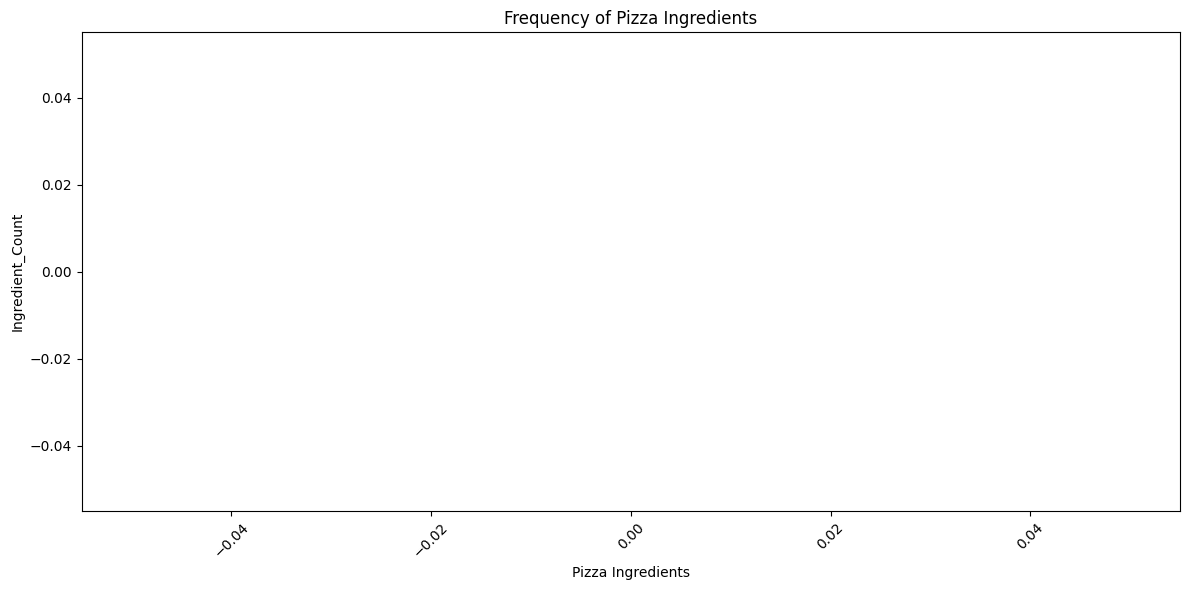

In [234]:
plt.figure(figsize = (12,6))
plt.bar(top10_ingredients.index,top10_ingredients.values)
plt.xlabel('Pizza Ingredients') 
plt.ylabel('Ingredient_Count')
plt.title('Frequency of Pizza Ingredients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [235]:
'''
Daily Trend

A line/bar chart showing sales by day of the week. Useful for staffing and operations planning.

'''

'\nDaily Trend\n\nA line/bar chart showing sales by day of the week. Useful for staffing and operations planning.\n\n'